# DSMarket — Tarea 2: Clustering de productos y tiendas

<div style="background-color:#2d8c4e;border-left:6px solid #2D8C4E;padding:14px;border-radius:10px">

**Objetivo del notebook**

Identificar grupos de productos con comportamiento similar para apoyar decisiones de negocio,
especialmente en marketing, lectura del surtido y análisis contextual.

Este notebook también incluye una exploración complementaria de clustering de tiendas,
pero el foco principal está en la segmentación de productos.

</div>

<a id="indice"></a>

## Índice

1. [Setup y carga de datos](#setup)
2. [Construcción de features por producto](#features-producto)
3. [Antes y después de `log1p`](#log1p)
4. [Preprocesado y escalado](#preprocesado)
5. [Selección de K](#seleccion-k)
6. [Clustering final e interpretación](#clustering-final)
7. [Validación por categoría](#validacion)
8. [Clustering de tiendas](#clustering-tiendas)
9. [Exportación](#exportacion)

## Razonamiento del notebook

La lógica de este análisis es la siguiente:

1. Resumir cada producto en un conjunto pequeño de features interpretables.
2. Corregir el efecto de distribuciones muy sesgadas.
3. Escalar las variables.
4. Agrupar productos por comportamiento similar.
5. Interpretar los clusters en lenguaje de negocio.

La importancia de este notbook es poder aportar una **capa contextual de segmentación.**


[⬆ Volver al índice](#indice)

In [1]:
# =============================================================================
# Imports y configuración global
# =============================================================================

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

SEED = 42
np.random.seed(SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

COLORS = {
    "primary":   "#2D8C4E",
    "secondary": "#F4A261",
    "accent":    "#E76F51",
    "neutral":   "#8ECAE6",
    "dark":      "#264653",
}

print(f"✅ Imports cargados | SEED={SEED}")

✅ Imports cargados | SEED=42


<a id="setup"></a>

## Setup y carga de datos

Este bloque es para dejar preparado un arranque portable, es decir que notebook pueda
ejecutarse en distintos entornos.

[⬆ Volver al índice](#indice)

In [2]:
# =============================================================================
# Rutas portables del proyecto
# =============================================================================

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR_DEFAULT = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

for path in [INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, OUTPUTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

REQUIRED_FILES = {
    "daily_calendar_with_events.csv",
    "item_prices.csv",
    "item_sales.csv",
}

def has_required_files(folder: Path) -> bool:
    return folder.is_dir() and REQUIRED_FILES.issubset({p.name for p in folder.iterdir() if p.is_file()})

def build_candidate_raw_dirs() -> list[Path]:
    candidates = []

    env_raw = os.getenv("DSMARKET_RAW_DIR")
    if env_raw:
        candidates.append(Path(env_raw))

    candidates.extend([
        PROJECT_ROOT / "data" / "raw",
        PROJECT_ROOT / "raw",
        PROJECT_ROOT.parent / "data" / "raw",
        Path("/content/DSMarket/data/raw"),
        Path("/content/drive/MyDrive/TFM MASTER/TFM/Mateo/data/raw"),
        Path("/kaggle/input/dsmarket"),
        Path("/kaggle/input/datasets/mateopascual/dsmarket"),
    ])

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for path in kaggle_input.iterdir():
            if path.is_dir():
                candidates.append(path)
                candidates.extend([sub for sub in path.iterdir() if sub.is_dir()])

    unique_candidates = []
    seen = set()

    for path in candidates:
        path = Path(path)
        if str(path) not in seen:
            unique_candidates.append(path)
            seen.add(str(path))

    return unique_candidates

def resolve_raw_dir() -> Path:
    candidates = build_candidate_raw_dirs()

    for candidate in candidates:
        if has_required_files(candidate):
            return candidate
        if has_required_files(candidate / "data" / "raw"):
            return candidate / "data" / "raw"
        if has_required_files(candidate / "raw"):
            return candidate / "raw"

    searched = "\n - ".join(str(p) for p in candidates[:20])
    raise FileNotFoundError(
        "No se encontró una carpeta válida con los archivos requeridos.\n"
        "Archivos esperados:\n"
        f" - {chr(10).join(sorted(REQUIRED_FILES))}\n\n"
        "Puedes definir manualmente la variable de entorno DSMARKET_RAW_DIR.\n"
        f"Primeras rutas revisadas:\n - {searched}"
    )

RAW_DIR = resolve_raw_dir()

print("✅ RAW_DIR resuelto:", RAW_DIR)

✅ RAW_DIR resuelto: /kaggle/input/datasets/mateopascual/dsmarket


In [3]:
# =============================================================================
# Carga de datos
# =============================================================================

sales_dtypes = {
    "item": "category",
    "store_code": "category",
    "category": "category",
}

prices_dtypes = {
    "item": "category",
    "store_code": "category",
}

df_sales = pd.read_csv(
    RAW_DIR / "item_sales.csv",
    dtype=sales_dtypes,
    low_memory=False
)

df_prices = pd.read_csv(
    RAW_DIR / "item_prices.csv",
    dtype=prices_dtypes,
    low_memory=False
)

df_cal = pd.read_csv(
    RAW_DIR / "daily_calendar_with_events.csv",
    parse_dates=["date"],
    low_memory=False
)

print("✅ Datos cargados")
print("df_sales :", df_sales.shape)
print("df_prices:", df_prices.shape)
print("df_cal   :", df_cal.shape)

✅ Datos cargados
df_sales : (30490, 1920)
df_prices: (6965706, 5)
df_cal   : (1913, 5)


In [4]:
# =============================================================================
# Validación inicial mínima
# =============================================================================

required_sales = {"item", "store_code", "category"}
required_prices = {"item", "store_code", "sell_price", "yearweek"}
required_cal = {"date", "d"}

missing_sales = required_sales - set(df_sales.columns)
missing_prices = required_prices - set(df_prices.columns)
missing_cal = required_cal - set(df_cal.columns)

if missing_sales:
    raise ValueError(f"Faltan columnas en df_sales: {missing_sales}")

if missing_prices:
    raise ValueError(f"Faltan columnas en df_prices: {missing_prices}")

if missing_cal:
    raise ValueError(f"Faltan columnas en df_cal: {missing_cal}")

day_cols = [c for c in df_sales.columns if re.fullmatch(r"d_\d+", str(c))]
day_cols = sorted(day_cols, key=lambda x: int(str(x).split("_")[1]))

if not day_cols:
    raise ValueError("No se detectaron columnas diarias tipo d_1, d_2, ... en df_sales")

print("✅ Estructura validada")
print(f"Número de columnas diarias: {len(day_cols):,}")
display(df_sales.head(3))
display(df_prices.head(3))
display(df_cal.head(3))

✅ Estructura validada
Número de columnas diarias: 1,913


,id,item,category,department,store,store_code,region,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,...,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,4,2,0,2,0,1,1,0,1,0,0,1,1,3,0,0,0,1,1,1,3,1,3,1,2,2,0,1,1,1,1,0,0,0,0,0,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6,1,1,2,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1


,item,category,store_code,yearweek,sell_price
0,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,328.0000",12.7414
1,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,329.0000",12.7414
2,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,330.0000",10.9858


,date,weekday,weekday_int,d,event
0,2011-01-29,Saturday,1,d_1,NaN
1,2011-01-30,Sunday,2,d_2,NaN
2,2011-01-31,Monday,3,d_3,NaN


<a id="features-producto"></a>

## Construcción de features por producto

Reducimos cada producto en un conjunto pequeño de variables interpretables. 

La intención es no tener que clusterizar sobre miles de columnas diarias, 
sino sobre un perfil compacto de comportamiento:

- Volumen medio.
- Volatilidad.
- Tendencia.
- Precio medio.
- Estacionalidad.

[⬆ Volver al índice](#indice)

In [5]:
# =============================================================================
# Feature engineering — Volumen y volatilidad por producto
# =============================================================================

df_item_daily = (
    df_sales
    .groupby("item", observed=True)[day_cols]
    .sum()
)

df_vol = pd.DataFrame(index=df_item_daily.index)
df_vol["total_units"] = df_item_daily.sum(axis=1)
df_vol["mean_units"] = df_item_daily.mean(axis=1)
df_vol["std_units"] = df_item_daily.std(axis=1)
df_vol["cv_units"] = df_vol["std_units"] / df_vol["mean_units"].clip(lower=1e-9)
df_vol["max_units"] = df_item_daily.max(axis=1)

df_vol = df_vol.reset_index()

print("✅ df_vol creado")
display(df_vol.head(10))

✅ df_vol creado


,item,total_units,mean_units,std_units,cv_units,max_units
0,ACCESORIES_1_001,4093,2.1396,2.6695,1.2477,15
1,ACCESORIES_1_002,5059,2.6445,2.3423,0.8857,24
2,ACCESORIES_1_003,1435,0.7501,1.4320,1.9089,11
3,ACCESORIES_1_004,39175,20.4783,8.2198,0.4014,61
4,ACCESORIES_1_005,14621,7.6430,4.9972,0.6538,35
5,ACCESORIES_1_006,13068,6.8312,5.8327,0.8538,52
6,ACCESORIES_1_007,3014,1.5755,1.6636,1.0559,8
7,ACCESORIES_1_008,87645,45.8155,27.2451,0.5947,153
8,ACCESORIES_1_009,15657,8.1845,5.4582,0.6669,37
9,ACCESORIES_1_010,11689,6.1103,3.0163,0.4936,24


In [6]:
# =============================================================================
# Feature engineering — Tendencia por producto
# =============================================================================

x = np.arange(df_item_daily.shape[1], dtype=float)

slopes = []

for item_id, row in df_item_daily.iterrows():
    y = row.values.astype(float)
    slope, intercept, r, p, se = stats.linregress(x, y)

    mean_y = y.mean()
    slope_norm = slope / mean_y if mean_y > 0 else 0.0

    slopes.append({
        "item": item_id,
        "trend_slope_norm": slope_norm
    })

df_trend = pd.DataFrame(slopes)

print("✅ df_trend creado")
display(df_trend.head(10))

✅ df_trend creado


,item,trend_slope_norm
0,ACCESORIES_1_001,0.0016
1,ACCESORIES_1_002,0.0001
2,ACCESORIES_1_003,0.0021
3,ACCESORIES_1_004,0.0001
4,ACCESORIES_1_005,0.0001
5,ACCESORIES_1_006,0.0004
6,ACCESORIES_1_007,0.0011
7,ACCESORIES_1_008,-0.0000
8,ACCESORIES_1_009,-0.0002
9,ACCESORIES_1_010,-0.0002


In [7]:
# =============================================================================
# Feature engineering — Precio medio por producto
# =============================================================================

df_prices_clean = df_prices.dropna(subset=["yearweek"]).copy()
df_prices_clean["yearweek"] = pd.to_numeric(df_prices_clean["yearweek"], errors="coerce")

if df_prices_clean["yearweek"].isna().any():
    raise ValueError("Hay yearweek no convertibles a numérico en df_prices.")

df_prices_clean["yearweek"] = df_prices_clean["yearweek"].round().astype(int)

df_price_feat = (
    df_prices_clean
    .groupby("item", observed=True)["sell_price"]
    .mean()
    .reset_index(name="avg_price")
)

print("✅ df_price_feat creado")
display(df_price_feat.head(5))

✅ df_price_feat creado


,item,avg_price
0,ACCESORIES_1_001,11.0328
1,ACCESORIES_1_002,5.2757
2,ACCESORIES_1_003,3.9441
3,ACCESORIES_1_004,5.9833
4,ACCESORIES_1_005,3.8321


In [8]:
# =============================================================================
# Feature engineering — Estacionalidad por producto
# =============================================================================

df_cal["month"] = df_cal["date"].dt.month
d_to_month = df_cal.set_index("d")["month"].to_dict()

month_cols = {}

for col in df_item_daily.columns:
    month = d_to_month.get(col)
    if month is not None:
        month_cols.setdefault(month, []).append(col)

rows = []

for item_id, row in df_item_daily.iterrows():
    monthly_means = []

    for month, cols in month_cols.items():
        monthly_means.append(row[cols].mean())

    monthly_means = np.array(monthly_means, dtype=float)
    mean_month = monthly_means.mean()

    seasonality_strength = (
        monthly_means.std() / mean_month if mean_month > 0 else 0.0
    )

    rows.append({
        "item": item_id,
        "seasonality_strength": seasonality_strength
    })

df_seas = pd.DataFrame(rows)

print("✅ df_seas creado")
display(df_seas.head(10))

✅ df_seas creado


,item,seasonality_strength
0,ACCESORIES_1_001,0.1850
1,ACCESORIES_1_002,0.3773
2,ACCESORIES_1_003,0.3109
3,ACCESORIES_1_004,0.0449
4,ACCESORIES_1_005,0.2125
5,ACCESORIES_1_006,0.0502
6,ACCESORIES_1_007,0.1567
7,ACCESORIES_1_008,0.0949
8,ACCESORIES_1_009,0.0521
9,ACCESORIES_1_010,0.0803


In [9]:
# =============================================================================
# Join de todas las features → df_features
# =============================================================================

df_features = (
    df_vol[["item", "mean_units", "cv_units"]]
    .merge(df_trend, on="item", how="left")
    .merge(df_price_feat, on="item", how="left")
    .merge(df_seas, on="item", how="left")
)

feat_cols = [
    "mean_units",
    "cv_units",
    "trend_slope_norm",
    "avg_price",
    "seasonality_strength"
]

for col in feat_cols:
    df_features[col] = df_features[col].fillna(df_features[col].median())

print("✅ df_features creado")
print("Shape:", df_features.shape)
display(df_features.head(10))

✅ df_features creado
Shape: (3049, 6)


,item,mean_units,cv_units,trend_slope_norm,avg_price,seasonality_strength
0,ACCESORIES_1_001,2.1396,1.2477,0.0016,11.0328,0.1850
1,ACCESORIES_1_002,2.6445,0.8857,0.0001,5.2757,0.3773
2,ACCESORIES_1_003,0.7501,1.9089,0.0021,3.9441,0.3109
3,ACCESORIES_1_004,20.4783,0.4014,0.0001,5.9833,0.0449
4,ACCESORIES_1_005,7.6430,0.6538,0.0001,3.8321,0.2125
5,ACCESORIES_1_006,6.8312,0.8538,0.0004,1.3343,0.0502
6,ACCESORIES_1_007,1.5755,1.0559,0.0011,10.4808,0.1567
7,ACCESORIES_1_008,45.8155,0.5947,-0.0000,0.6329,0.0949
8,ACCESORIES_1_009,8.1845,0.6669,-0.0002,2.2907,0.0521
9,ACCESORIES_1_010,6.1103,0.4936,-0.0002,3.9564,0.0803


<a id="log1p"></a>

## Antes y después de `log1p`

Algunas variables del clustering presentan una distribución muy sesgada a la derecha,
especialmente las relacionadas con volumen y dispersión.

Por eso aplicamos una transformación logarítmica natural (`log1p`) antes del escalado.
La intención **reducir su peso relativo** y hacer comparables productos muy distintos en escala.

[⬆ Volver al índice](#indice)

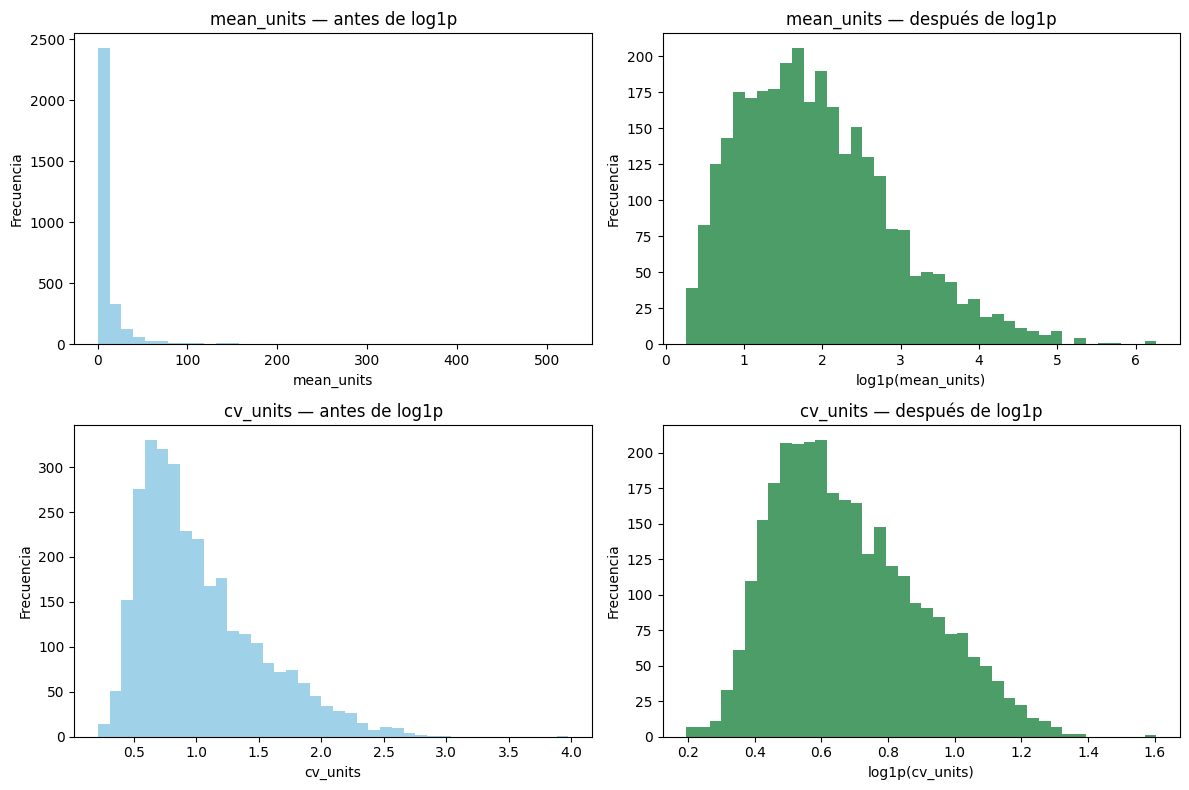

In [10]:
# =============================================================================
# Visualización antes y después de log1p
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df_features["mean_units"], bins=40, color=COLORS["neutral"], alpha=0.85)
axes[0, 0].set_title("mean_units — antes de log1p")
axes[0, 0].set_xlabel("mean_units")
axes[0, 0].set_ylabel("Frecuencia")

axes[0, 1].hist(np.log1p(df_features["mean_units"]), bins=40, color=COLORS["primary"], alpha=0.85)
axes[0, 1].set_title("mean_units — después de log1p")
axes[0, 1].set_xlabel("log1p(mean_units)")
axes[0, 1].set_ylabel("Frecuencia")

axes[1, 0].hist(df_features["cv_units"], bins=40, color=COLORS["neutral"], alpha=0.85)
axes[1, 0].set_title("cv_units — antes de log1p")
axes[1, 0].set_xlabel("cv_units")
axes[1, 0].set_ylabel("Frecuencia")

axes[1, 1].hist(np.log1p(df_features["cv_units"]), bins=40, color=COLORS["primary"], alpha=0.85)
axes[1, 1].set_title("cv_units — después de log1p")
axes[1, 1].set_xlabel("log1p(cv_units)")
axes[1, 1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

<a id="preprocesado"></a>

## Preprocesado y escalado

Después de comprobar visualmente el sesgo positivo de algunas variables,
aplicamos `log1p` y estadarizamos todas las features.

Con ello pretendemos evitar que el clustering quede dominado por variables con
una cola extrema mucho mayor que las demás.


[⬆ Volver al índice](#indice)

In [11]:
# =============================================================================
# Preprocesado — log1p + escalado
# =============================================================================

feat_cols = [
    "mean_units",
    "cv_units",
    "trend_slope_norm",
    "avg_price",
    "seasonality_strength"
]

df_to_scale = df_features[feat_cols].copy()

log_cols = ["mean_units", "cv_units"]

for col in log_cols:
    df_to_scale[col] = np.log1p(df_to_scale[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_to_scale)

print("✅ Preprocesado completado")
print("Shape X_scaled:", X_scaled.shape)

✅ Preprocesado completado
Shape X_scaled: (3049, 5)


<a id="seleccion-k"></a>

## Selección de K

Vamos a comparar los valores de 'K' usando dos criterios:


- **Método del codo** para ver reducción de inercia.
- **Coeficiente de silueta** para medir separación relativa entre clusters.



[⬆ Volver al índice](#indice)

⏳ Calculando K-Means para K=2 a K=12...
K= 2 | Inercia=9,973.26 | Silueta=0.3541
K= 3 | Inercia=8,294.05 | Silueta=0.2607
K= 4 | Inercia=7,080.87 | Silueta=0.2914
K= 5 | Inercia=5,915.48 | Silueta=0.2545
K= 6 | Inercia=5,372.30 | Silueta=0.2285
K= 7 | Inercia=4,913.43 | Silueta=0.2379
K= 8 | Inercia=4,543.89 | Silueta=0.2325
K= 9 | Inercia=4,208.12 | Silueta=0.2391
K=10 | Inercia=3,958.70 | Silueta=0.2384
K=11 | Inercia=3,755.72 | Silueta=0.2395
K=12 | Inercia=3,573.98 | Silueta=0.2205


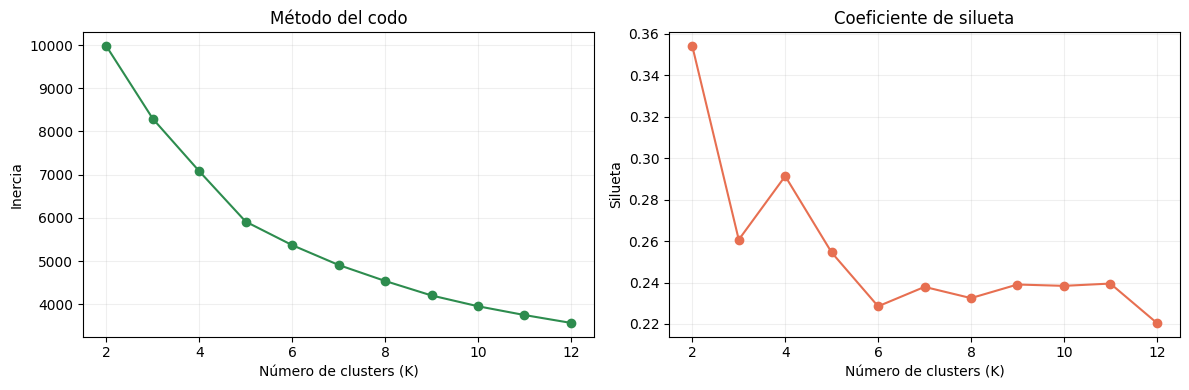

In [12]:
# =============================================================================
# Selección de K — Método del codo + coeficiente de silueta
# =============================================================================

K_range = range(2, 13)
inertias = []
silhouettes = []

print("⏳ Calculando K-Means para K=2 a K=12...")

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)

    sil = silhouette_score(
        X_scaled,
        labels,
        sample_size=min(1000, len(df_features)),
        random_state=SEED
    )
    silhouettes.append(sil)

    print(f"K={k:2d} | Inercia={km.inertia_:,.2f} | Silueta={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, marker="o", color=COLORS["primary"])
axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("Inercia")
axes[0].grid(alpha=0.20)

axes[1].plot(list(K_range), silhouettes, marker="o", color=COLORS["accent"])
axes[1].set_title("Coeficiente de silueta")
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Silueta")
axes[1].grid(alpha=0.20)

plt.tight_layout()
plt.show()

<a id="clustering-final"></a>

## Clustering final e interpretación

A partir de la comparación entre inercia y coeficiente de silueta, se selecciona `K = 4` como valor final para el clustering de productos.

La decisión no se basa únicamente en maximizar la silueta.
Aunque `K = 2` presenta el valor más alto, ese nivel de partición resulta demasiado grueso para los fines interpretativos del proyecto.

`K = 4` ofrece un equilibrio más razonable entre:

- Separación aceptable entre grupos.
- Reducción de inercia.
- Utilidad de negocio para interpretar perfiles de producto.



[⬆ Volver al índice](#indice)

In [13]:
# =============================================================================
# Clustering final de productos
# =============================================================================

K_FINAL = 4

kmeans = KMeans(
    n_clusters=K_FINAL,
    n_init=10,
    random_state=SEED
)

df_features["cluster"] = kmeans.fit_predict(X_scaled)

cluster_sizes = (
    df_features["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("n_items")
    .reset_index()
    .rename(columns={"index": "cluster"})
)

print("✅ Clustering final completado")
print(f"K final: {K_FINAL}")
display(cluster_sizes)

✅ Clustering final completado
K final: 4


,cluster,n_items
0,0,221
1,1,1439
2,2,766
3,3,623


In [14]:
# =============================================================================
# Perfil medio por cluster
# =============================================================================

df_profile = (
    df_features.groupby("cluster", as_index=False)[feat_cols]
    .mean()
)

display(df_profile.round(4))

,cluster,mean_units,cv_units,trend_slope_norm,avg_price,seasonality_strength
0,0,4.3979,1.6410,0.0009,5.6917,0.5919
1,1,19.9396,0.6977,0.0001,3.5988,0.1462
2,2,3.2996,1.5244,0.0016,4.6326,0.2133
3,3,3.4495,0.9573,0.0003,11.2169,0.1660


In [15]:
# =============================================================================
# Perfil medio por cluster
# =============================================================================

df_profile = (
    df_features.groupby("cluster", as_index=False)[feat_cols]
    .mean()
)

display(df_profile.round(4))

,cluster,mean_units,cv_units,trend_slope_norm,avg_price,seasonality_strength
0,0,4.3979,1.6410,0.0009,5.6917,0.5919
1,1,19.9396,0.6977,0.0001,3.5988,0.1462
2,2,3.2996,1.5244,0.0016,4.6326,0.2133
3,3,3.4495,0.9573,0.0003,11.2169,0.1660


In [16]:
# =============================================================================
# Resumen interpretativo por cluster
# =============================================================================

df_summary = (
    df_features.groupby("cluster", as_index=False)
    .agg(
        n_items=("item", "count"),
        mean_units=("mean_units", "mean"),
        cv_units=("cv_units", "mean"),
        trend_slope_norm=("trend_slope_norm", "mean"),
        avg_price=("avg_price", "mean"),
        seasonality_strength=("seasonality_strength", "mean")
    )
    .sort_values("cluster")
    .reset_index(drop=True)
)

display(df_summary.round(4))

,cluster,n_items,mean_units,cv_units,trend_slope_norm,avg_price,seasonality_strength
0,0,221,4.3979,1.6410,0.0009,5.6917,0.5919
1,1,1439,19.9396,0.6977,0.0001,3.5988,0.1462
2,2,766,3.2996,1.5244,0.0016,4.6326,0.2133
3,3,623,3.4495,0.9573,0.0003,11.2169,0.1660


In [17]:
# =============================================================================
# Asignación de nombres de negocio a los clusters
# =============================================================================

cluster_names = {
    0: "Seasonal volatile",
    1: "Core steady sellers",
    2: "Low-volume volatile",
    3: "Premium niche",
}

df_features["cluster_name"] = df_features["cluster"].map(cluster_names)
df_summary["cluster_name"] = df_summary["cluster"].map(cluster_names)

display(df_summary.round(4))

,cluster,n_items,mean_units,cv_units,trend_slope_norm,avg_price,seasonality_strength,cluster_name
0,0,221,4.3979,1.6410,0.0009,5.6917,0.5919,Seasonal volatile
1,1,1439,19.9396,0.6977,0.0001,3.5988,0.1462,Core steady sellers
2,2,766,3.2996,1.5244,0.0016,4.6326,0.2133,Low-volume volatile
3,3,623,3.4495,0.9573,0.0003,11.2169,0.1660,Premium niche


Los resultados del clustering muestran que una segmentación en **4 grupos** resulta interpretable y útil para negocio.

La estructura obtenida organiza los productos integrando el volumne con una combinación de:

- Estabilidad de la demanda.
- Sensibilidad estacional.
- Nivel de precio.
- Variabilidad semanal.

### Lectura de los clusters

- **Cluster 1 — Core steady sellers**  
  Es el grupo más grande y concentra productos de mayor rotación, menor volatilidad relativa y precio medio más bajo. Representa el núcleo más estable del surtido.

- **Cluster 0 — Seasonal volatile**  
  Agrupa productos con fuerte componente estacional y alta variabilidad. Aunque no son los de mayor volumen, sí presentan un comportamiento más irregular y sensible a picos temporales.

- **Cluster 2 — Low-volume volatile**  
  Reúne productos de baja rotación y alta volatilidad, con una ligera señal de crecimiento relativo. Se interpreta mejor como un grupo inestable o de comportamiento menos consolidado que como una categoría de crecimiento fuerte.

- **Cluster 3 — Premium niche**  
  Incluye productos de precio medio claramente superior, baja rotación y volatilidad moderada. Su perfil encaja con una lógica de nicho premium.

### Conclusión de negocio

El clustering aporta una segmentación útil para contextualizar el surtido y enriquecer la lectura del negocio.
Sin embargo, dentro del proyecto DSMarket su papel debe entenderse como **capa analítica complementaria**,
no como la base principal del forecasting.

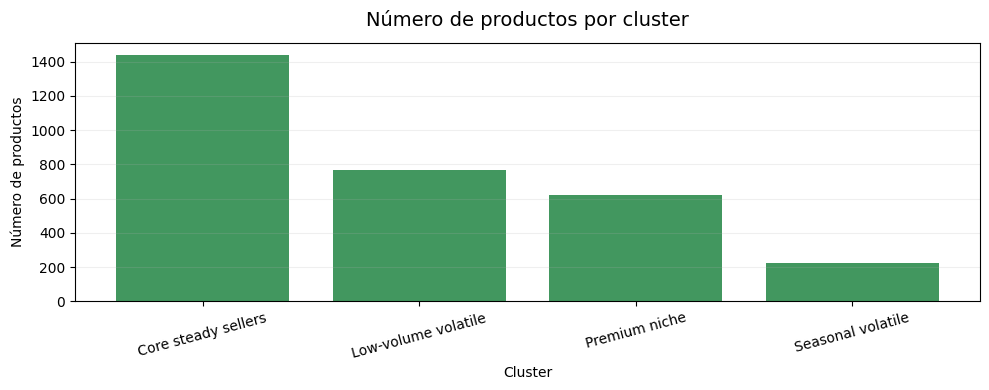

In [18]:
# =============================================================================
# Tamaño de clusters
# =============================================================================

cluster_sizes_plot = (
    df_features["cluster_name"]
    .value_counts()
    .reset_index()
)

cluster_sizes_plot.columns = ["cluster_name", "n_items"]

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    cluster_sizes_plot["cluster_name"],
    cluster_sizes_plot["n_items"],
    color=COLORS["primary"],
    alpha=0.90
)

ax.set_title("Número de productos por cluster", fontsize=14, pad=12)
ax.set_xlabel("Cluster")
ax.set_ylabel("Número de productos")
ax.grid(axis="y", alpha=0.20)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [19]:
# =============================================================================
# Composición por categoría dentro de cada cluster
# =============================================================================

df_cat_map = (
    df_sales[["item", "category"]]
    .drop_duplicates()
)

df_cluster_cat = (
    df_features[["item", "cluster_name"]]
    .merge(df_cat_map, on="item", how="left")
)

cluster_category_share = (
    pd.crosstab(df_cluster_cat["cluster_name"], df_cluster_cat["category"], normalize="index") * 100
)

display(cluster_category_share.round(2))

category,ACCESORIES,HOME_&_GARDEN,SUPERMARKET
cluster_name,,,
Core steady sellers,11.1200,26.5500,62.3300
Low-volume volatile,20.6300,33.1600,46.2100
Premium niche,34.0300,51.6900,14.2900
Seasonal volatile,15.8400,40.2700,43.8900


## Visualización e interpretación de los clusters

Aquí interpretamos la salida del clustering a una lectura más visual y mas clara para el negocio. 

La idea es responder tres preguntas:

1. ¿En qué se diferencia cada cluster a nivel de comportamiento medio?
2. ¿Cómo se posicionan los clusters en términos de volumen y volatilidad?
3. ¿Hasta qué punto la composición por categoría ayuda a interpretar los grupos?

[⬆ Volver al índice](#indice)

In [20]:
# =============================================================================
# Nombres finales de clusters
# =============================================================================

cluster_names = {
    0: "Estacionales volátiles",
    1: "Básicos de alto volumen",
    2: "Baja rotación volátil",
    3: "Nicho premium",
}

df_features["cluster_name"] = df_features["cluster"].map(cluster_names)
df_summary["cluster_name"] = df_summary["cluster"].map(cluster_names)

display(df_summary.round(4))

,cluster,n_items,mean_units,cv_units,trend_slope_norm,avg_price,seasonality_strength,cluster_name
0,0,221,4.3979,1.6410,0.0009,5.6917,0.5919,Estacionales volátiles
1,1,1439,19.9396,0.6977,0.0001,3.5988,0.1462,Básicos de alto volumen
2,2,766,3.2996,1.5244,0.0016,4.6326,0.2133,Baja rotación volátil
3,3,623,3.4495,0.9573,0.0003,11.2169,0.1660,Nicho premium


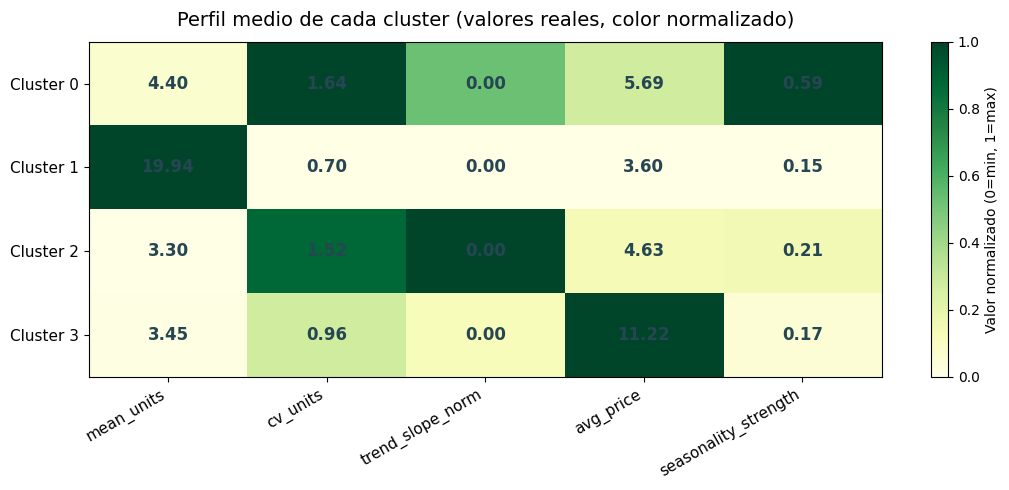

In [21]:
# =============================================================================
# Heatmap del perfil medio por cluster
# =============================================================================
heatmap_df = (
    df_summary[
        ["cluster", "mean_units", "cv_units", "trend_slope_norm", "avg_price", "seasonality_strength"]
    ]
    .copy()
    .set_index("cluster")
)
heatmap_norm = (heatmap_df - heatmap_df.min()) / (heatmap_df.max() - heatmap_df.min())

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(heatmap_norm.values, aspect="auto", cmap="YlGn", vmin=0, vmax=1)

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=30, ha="right", fontsize=11)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels([f"Cluster {c}" for c in heatmap_df.index], fontsize=11)

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        ax.text(
            j,
            i,
            f"{heatmap_df.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="#264653"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Valor normalizado (0=min, 1=max)", fontsize=10)
ax.set_title("Perfil medio de cada cluster (valores reales, color normalizado)", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

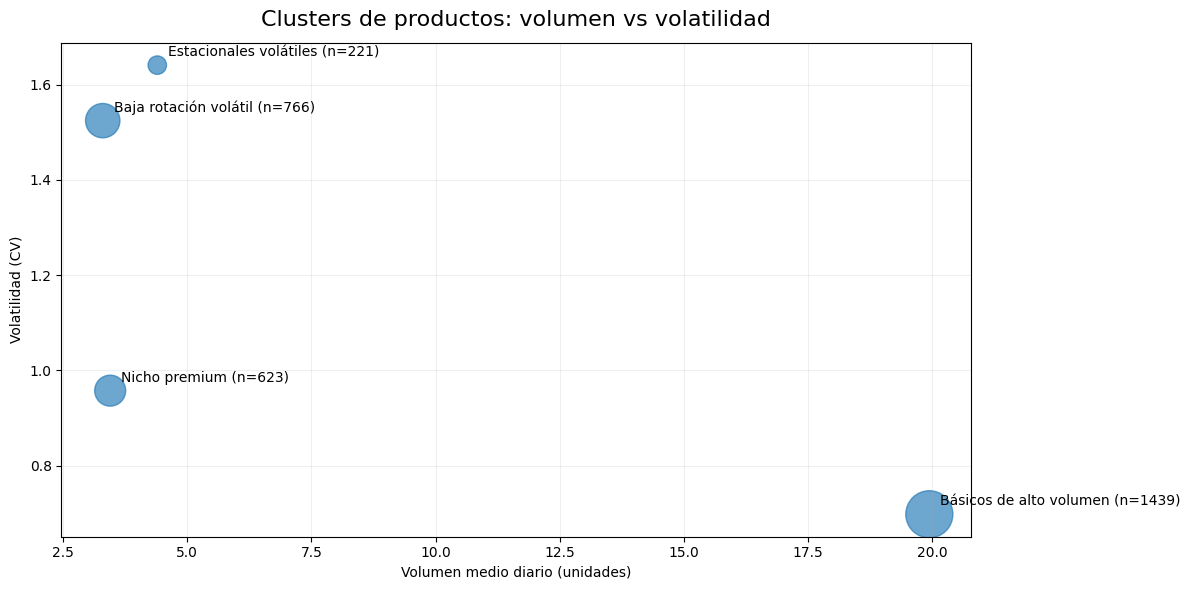

In [22]:
# =============================================================================
# Bubble chart: volumen vs volatilidad
# =============================================================================

plot_df = df_summary.copy()

fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(
    plot_df["mean_units"],
    plot_df["cv_units"],
    s=plot_df["n_items"] * 0.8,
    alpha=0.65
)

for _, row in plot_df.iterrows():
    ax.annotate(
        f"{row['cluster_name']} (n={int(row['n_items'])})",
        (row["mean_units"], row["cv_units"]),
        xytext=(8, 6),
        textcoords="offset points",
        fontsize=10
    )

ax.set_title("Clusters de productos: volumen vs volatilidad", fontsize=16, pad=12)
ax.set_xlabel("Volumen medio diario (unidades)")
ax.set_ylabel("Volatilidad (CV)")
ax.grid(alpha=0.20)

plt.tight_layout()
plt.show()

In [23]:
# =============================================================================
# Composición por categoría dentro de cada cluster
# =============================================================================

df_cat_map = (
    df_sales[["item", "category"]]
    .drop_duplicates()
)

df_cluster_cat = (
    df_features[["item", "cluster_name"]]
    .merge(df_cat_map, on="item", how="left")
)

cluster_category_share = (
    pd.crosstab(
        df_cluster_cat["cluster_name"],
        df_cluster_cat["category"],
        normalize="index"
    ) * 100
)

display(cluster_category_share.round(2))

category,ACCESORIES,HOME_&_GARDEN,SUPERMARKET
cluster_name,,,
Baja rotación volátil,20.6300,33.1600,46.2100
Básicos de alto volumen,11.1200,26.5500,62.3300
Estacionales volátiles,15.8400,40.2700,43.8900
Nicho premium,34.0300,51.6900,14.2900


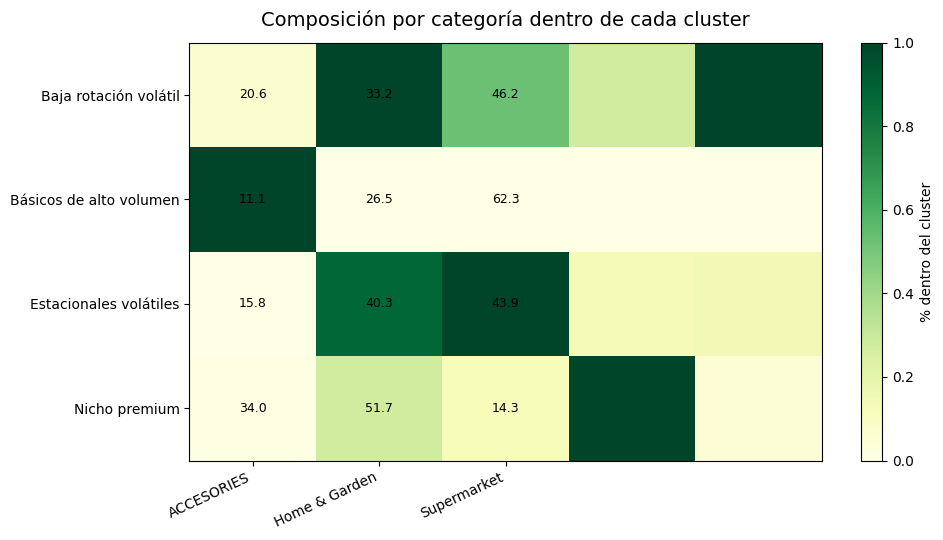

In [24]:
# =============================================================================
# Heatmap de composición por categoría
# =============================================================================

cat_df = cluster_category_share.copy()

# Etiquetas más legibles solo para visualización
pretty_cols = {
    "ACCESSORIES": "Accessories",
    "HOME_&_GARDEN": "Home & Garden",
    "SUPERMARKET": "Supermarket",
}

cat_plot = cat_df.copy()
cat_plot.columns = [pretty_cols.get(col, col) for col in cat_plot.columns]

fig, ax = plt.subplots(figsize=(10, 5.5))

im = ax.imshow(heatmap_norm.values, aspect="auto", cmap="YlGn", vmin=0, vmax=1)

ax.set_xticks(range(len(cat_plot.columns)))
ax.set_xticklabels(cat_plot.columns, rotation=25, ha="right")

ax.set_yticks(range(len(cat_plot.index)))
ax.set_yticklabels(cat_plot.index)

for i in range(cat_plot.shape[0]):
    for j in range(cat_plot.shape[1]):
        ax.text(
            j,
            i,
            f"{cat_plot.iloc[i, j]:.1f}",
            ha="center",
            va="center",
            fontsize=9,
            color="black"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("% dentro del cluster")

ax.set_title("Composición por categoría dentro de cada cluster", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

## Interpretación de los clusters de producto

La solución final con **K = 4** genera una segmentación interpretable y útil para negocio.

Los grupos obtenidos se diferencian por una combinación de:

- Volumen medio.
- Volatilidad.
- Nivel de precio.
- Fuerza estacional.

Además, la validación por categoría muestra que los clusters no son una simple copia de la taxonomía del surtido, aunque sí recogen parte de esa estructura, algo razonable en un contexto retail.

### Lectura de los clusters

- **Básicos de alto volumen**  
  Es el grupo más grande y concentra productos de mayor rotación, menor volatilidad relativa y precio medio más bajo.  
  Su composición está claramente dominada por **SUPERMARKET**, por lo que puede interpretarse como el núcleo más estable y masivo del surtido.

- **Estacionales volátiles**  
  Agrupa productos con fuerte componente estacional y alta variabilidad.  
  Su composición se reparte principalmente entre **SUPERMARKET** y **HOME & GARDEN**, lo que sugiere que la estacionalidad no se limita a una única categoría, sino que aparece de forma más transversal.

- **Baja rotación volátil**  
  Reúne productos de baja rotación y alta volatilidad, con una composición más mixta entre categorías.  
  Esta mezcla refuerza la idea de que el cluster está captando comportamiento de demanda más que una simple agrupación taxonómica.

- **Nicho premium**  
  Incluye productos de precio medio claramente superior, baja rotación y volatilidad moderada.  
  Está dominado por **HOME & GARDEN** y **ACCESSORIES**, con un peso menor de **SUPERMARKET**, lo que refuerza su interpretación como surtido más específico y menos core.

### Conclusión de negocio

El clustering aporta una capa útil para entender mejor la estructura del surtido y segmentar productos por comportamiento.


[⬆ Volver al índice](#indice)

<a id="clustering-tiendas"></a>

## Clustering de tiendas

Como análisis complementario, se explora también una segmentación de tiendas a partir de su perfil agregado de demanda y precio medio.

Este bloque debe interpretarse con prudencia:
con solo 10 tiendas, el clustering no pretende ofrecer una estructura de catálogo definitiva,
sino una exploración preliminar de posibles tipologías operativas.

[⬆ Volver al índice](#indice)

In [25]:
# =============================================================================
# Clustering de tiendas
# =============================================================================
# Propósito:
#   - Agrupar las 10 tiendas por perfil de demanda
# Inputs:
#   - df_sales (item, store_code, d_*)
#   - df_prices_clean (item, store_code, sell_price)
# Outputs:
#   - df_store_feat: perfil por tienda + cluster asignado
# Decisiones:
#   - Features: mean_units, cv_units, total_units, avg_price por tienda
#   - K=3 como hipótesis inicial
#   - Con solo 10 tiendas, K-Means es exploratorio y no concluyente
# =============================================================================

day_cols = [c for c in df_sales.columns if c.startswith("d_")]

df_store_daily = (
    df_sales
    .groupby("store_code", observed=True)[day_cols]
    .sum()
)

df_store_feat = pd.DataFrame(index=df_store_daily.index)
df_store_feat["mean_units"] = df_store_daily.mean(axis=1)
df_store_feat["cv_units"] = (
    df_store_daily.std(axis=1) / df_store_daily.mean(axis=1).clip(lower=1e-9)
)
df_store_feat["total_units"] = df_store_daily.sum(axis=1)
df_store_feat = df_store_feat.reset_index()

df_store_price = (
    df_prices_clean
    .groupby("store_code", observed=True)["sell_price"]
    .mean()
    .reset_index(name="avg_price")
)

df_store_feat = df_store_feat.merge(df_store_price, on="store_code", how="left")

df_store_feat["city"] = (
    df_store_feat["store_code"]
    .astype(str)
    .str.split("_")
    .str[0]
    .str.upper()
)

store_feat_cols = ["mean_units", "cv_units", "total_units", "avg_price"]

X_store = StandardScaler().fit_transform(df_store_feat[store_feat_cols].values)

km_store = KMeans(n_clusters=3, n_init=20, random_state=SEED)
df_store_feat["cluster"] = km_store.fit_predict(X_store)

print("✅ Clustering de tiendas completado")
display(
    df_store_feat[
        ["store_code", "city", "mean_units", "cv_units", "avg_price", "total_units", "cluster"]
    ].sort_values("cluster")
)

✅ Clustering de tiendas completado


,store_code,city,mean_units,cv_units,avg_price,total_units,cluster
0,BOS_1,BOS,"2,924.8782",0.2102,5.4658,5595292,0
1,BOS_2,BOS,"3,771.2410",0.2102,5.4557,7214384,0
2,BOS_3,BOS,"3,183.1312",0.2141,5.4844,6089330,0
3,NYC_1,NYC,"4,024.1589",0.2465,5.5161,7698216,0
6,NYC_4,NYC,"2,145.1521",0.1995,5.5227,4103676,0
9,PHI_3,PHI,"3,360.0533",0.2457,5.5207,6427782,0
7,PHI_1,PHI,"2,691.6163",0.3705,5.5802,5149062,1
4,NYC_2,NYC,"2,972.0204",0.3028,5.5764,5685475,1
8,PHI_2,PHI,"3,420.8113",0.3756,5.5555,6544012,1
5,NYC_3,NYC,"5,848.4997",0.2053,5.4836,11188180,2


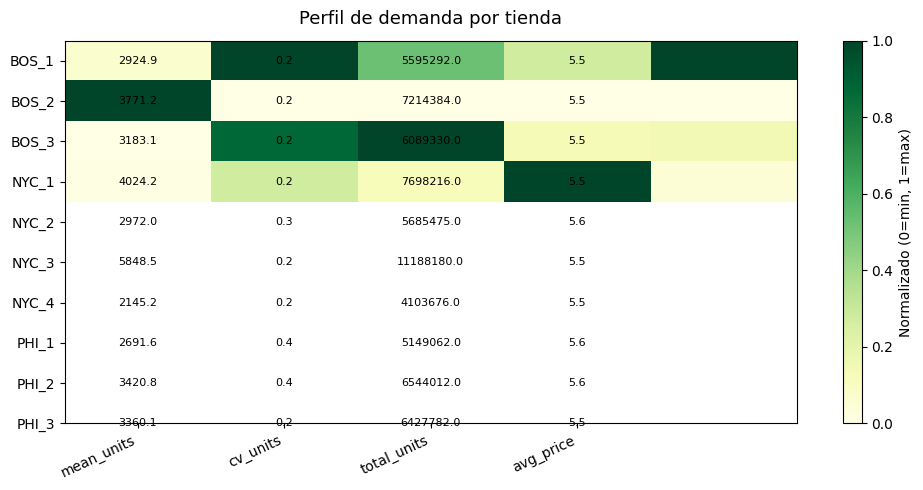

In [26]:
# =============================================================================
# Heatmap de perfil por tienda
# =============================================================================

pivot = df_store_feat.set_index("store_code")[store_feat_cols].copy()
pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min())

fig, ax = plt.subplots(figsize=(10, 5))

im = ax.imshow(heatmap_norm.values, aspect="auto", cmap="YlGn", vmin=0, vmax=1)

ax.set_xticks(range(len(store_feat_cols)))
ax.set_xticklabels(store_feat_cols, rotation=25, ha="right")

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index.tolist())

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(
            j,
            i,
            f"{pivot.iloc[i, j]:.1f}",
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Normalizado (0=min, 1=max)")

ax.set_title("Perfil de demanda por tienda", fontsize=13, pad=12)

plt.tight_layout()
plt.show()

### Lectura del clustering de tiendas

La segmentación de tiendas constituye una aproximación exploratoria inicial que sienta las bases para futuros análisis más profundos.

Dada la muestra de 10 tiendas, el objetivo principal es validar la existencia de perfiles de demanda diferenciados que permitan justificar estrategias operativas personalizadas. Este enfoque permite identificar patrones clave de comportamiento, priorizando la agilidad analítica sobre la creación de una clasificación definitiva o rígida.

La utilidad fundamental de este bloque reside en demostrar que el comportamiento de una tienda es el resultado de integrar su ubicación geográfica con sus propios indicadores de volumen, variabilidad y nivel de precio medio. De este modo, se obtiene una visión mucho más rica y multidimensional de cada punto de venta.

[⬆ Volver al índice](#indice)

<a id="exportacion"></a>

## Exportación

En este bloque guardo los resultados finales del clustering de productos y tiendas
en un formato reutilizable para reporting, revisión y apoyo a Power BI.

[⬆ Volver al índice](#indice)

In [27]:
# =============================================================================
# Exportación final
# =============================================================================

EXPORT_DIR = OUTPUTS_DIR / "clustering_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

cols_export_prod = [
    "item",
    "cluster",
    "cluster_name",
    "mean_units",
    "cv_units",
    "avg_price",
    "trend_slope_norm",
    "seasonality_strength",
]

df_features[cols_export_prod].to_csv(
    EXPORT_DIR / "clusters_productos.csv",
    index=False
)

print(f"✅ clusters_productos.csv guardado ({len(df_features):,} filas)")

store_cluster_names = {
    0: "Tiendas estables",
    1: "Tiendas volátiles",
    2: "Tienda flagship",
}

df_store_feat["cluster_name"] = df_store_feat["cluster"].map(store_cluster_names)

cols_export_store = [
    "store_code",
    "city",
    "cluster",
    "cluster_name",
    "mean_units",
    "cv_units",
    "avg_price",
    "total_units",
]

df_store_feat[cols_export_store].to_csv(
    EXPORT_DIR / "clusters_tiendas.csv",
    index=False
)

print(f"✅ clusters_tiendas.csv guardado ({len(df_store_feat):,} filas)")
print("✅ Exportación final completada")
print("Ruta:", EXPORT_DIR.resolve())

✅ clusters_productos.csv guardado (3,049 filas)
✅ clusters_tiendas.csv guardado (10 filas)
✅ Exportación final completada
Ruta: /kaggle/working/outputs/clustering_exports


<div style="background-color:#2d8c4e; border:1px solid #ddd; border-radius:10px; padding:30px; font-family:Arial, sans-serif; max-width:700px">

<p style="color:#000000; font-size:0.85em; margin-bottom:4px">De: Nicole Chen — Data Scientist Senior</p>
<p style="color:#000000; font-size:0.85em; margin-bottom:4px">Para: Joelle (Marketing Manager)</p>
<p style="color:#000000; font-size:0.85em; margin-bottom:4px">CC: Paul Rogers (CFO) · Michelle Huggins (CDO)</p>
<p style="color:#000000; font-size:0.85em; margin-bottom:20px">Asunto: Re: Segmentación de productos y tiendas — resultados</p>

<p>Hola Joelle,</p>

<p>Gracias por el encargo. He terminado el análisis y te cuento lo que encontré.</p>

<p>Para los productos, probé distintas configuraciones y la respuesta a tu pregunta es <strong>4 grupos</strong>. 
Con 5 o más, los clusters empiezan a solaparse y pierden interpretabilidad para negocio. 
Con menos de 4, mezclamos comportamientos demasiado distintos. 
Aquí están los cuatro perfiles:</p>

<ul>
  <li><strong>Básicos de alto volumen</strong> (47% del catálogo): el motor del negocio. 
  Venden ~20 unidades/día a un precio medio de $3.59. Comportamiento muy estable.</li>
  <li><strong>Premium</strong> (21%): ticket alto (~$11), rotación más baja pero predecible. 
  Son los productos que más impacto tienen en revenue por unidad.</li>
  <li><strong>Baja rotación volátil</strong> (26%): tendencia positiva pero difíciles de predecir. 
  Interesantes para campañas, pero requieren más seguimiento.</li>
  <li><strong>Estacionales volátiles</strong> (7%): el grupo de mayor riesgo de rotura. 
  Estacionalidad alta y comportamiento errático. Aquí es donde más se puede perder.</li>
</ul>

<p>Para las tiendas, la respuesta es <strong>3 grupos</strong>: tiendas estables (6), 
tiendas volátiles (3) y NYC_3, que opera en una categoría aparte por volumen y comportamiento. 
Un dato relevante: la ciudad de la tienda no predice a qué grupo pertenece. 
Hay tiendas volátiles en NYC y tiendas estables en Philadelphia.</p>

<p>En cuanto al uso de estos resultados: los clusters de producto los incorporo como 
feature en el modelo de forecasting (Tarea 3). No son el pilar del modelo, 
pero añaden contexto que mejora la segmentación de la predicción. 
Para marketing, el grupo de <em>crecimiento volátil</em> es el más interesante 
para campañas porque tiene tracción pero aún no ha estabilizado su base de clientes.</p>

<p>Quedo disponible si quieres profundizar en algún grupo concreto.</p>

<p>Un saludo,<br>
<strong>Nicole Chen</strong><br>
<span style="color:#2D8C4E">Data Scientist Senior — DSMarket</span></p>

</div>
[⬆ Volver al índice](#indice)